<a href="https://colab.research.google.com/github/jceltruda/Projects-in-AI-and-ML/blob/main/ML_AI_Projects_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###**Task 1**

**Task 1: Part A**

In [ ]:
# Setup
import torch
import numpy as np
import random
import sys
import os

# Record colab environment
print("Record environment:")
print(f"Python version: {sys.version.split(' ')[0]}")
print(f"PyTorch version: {torch.__version__}")
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
print(f"GPU Type: {gpu_name}")

# Fix seed
seed = 15
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Get nanoGPT
!git clone https://github.com/karpathy/nanoGPT.git
%cd nanoGPT
!pip install -q datasets tiktoken wandb tqdm
!python data/shakespeare_char/prepare.py

# Calculate steps_per_epoch
num_train_tokens = 1003854 # tokens in dataset
# Using default config:
batch_size = 64
block_size = 256

steps_per_epoch = int(np.floor(num_train_tokens / (batch_size * block_size)))
print(f"\nSteps per epoch: {steps_per_epoch}")
print(f" Steps in 5 epochs: {steps_per_epoch * 5}")
print(f" Steps in 50 epochs: {steps_per_epoch * 50}")
print(f" Steps in 500 epochs: {steps_per_epoch * 500}")

Record environment:
Python version: 3.12.12
PyTorch version: 2.10.0+cu128
GPU Type: NVIDIA H100 80GB HBM3
Cloning into 'nanoGPT'...
remote: Enumerating objects: 689, done.
remote: Total 689 (delta 0), reused 0 (delta 0), pack-reused 689 (from 1)
Receiving objects: 100% (689/689), 975.24 KiB | 3.21 MiB/s, done.
Resolving deltas: 100% (382/382), done.
/content/nanoGPT
length of dataset in characters: 1,115,394
all the unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocab size: 65
train has 1,003,854 tokens
val has 111,540 tokens

Steps per epoch: 61
 Steps in 5 epochs: 305
 Steps in 50 epochs: 3050
 Steps in 500 epochs: 30500


In [ ]:
# Train 5 epochs
!python train.py config/train_shakespeare_char.py \
    --max_iters=305 --eval_interval=305 --always_save_checkpoint=True \
    --out_dir=out-shakespeare-char

Overriding config with config/train_shakespeare_char.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 5000
lr_decay_iters = 5000 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.99 # make a bit bigger because number of 

In [ ]:
# Generate sample 1
!python sample.py \
    --out_dir=out-shakespeare-char \
    --start="ROMEO: Juliet, I want " \
    --num_samples=1 \
    --max_new_tokens=500 \
    --temperature=0.8 \
    --top_k=200

Overriding: out_dir = out-shakespeare-char
Overriding: start = ROMEO: Juliet, I want 
Overriding: num_samples = 1
Overriding: max_new_tokens = 500
Overriding: temperature = 0.8
Overriding: top_k = 200
number of parameters: 10.65M
Loading meta from data/shakespeare_char/meta.pkl...
ROMEO: Juliet, I want the they beidce.

SORTHUTES:
How it to of ould and On them all ands:
Whith fould all but hearlaccaue are rume.

GRER:
An I muse on the of is heart my helit.

KING RICHARD IIIII:
Your drove to heart not and.

WARWICK:
No dise his humme new have up; and the ty most made.
Bod and gook hom the shall make on thou dude evicesseest
For His and shim compooce
And sighte king thrust for ar is him shall.

RICHURD:
That Prie, I have am I lood stimbless
ards beaces and thiu him to mare no Rreats chan the may
---------------


In [ ]:
# Train 50 epochs
!python train.py config/train_shakespeare_char.py \
    --init_from='resume' --max_iters=3050 --eval_interval=2745 --always_save_checkpoint=True \
    --out_dir=out-shakespeare-char

Overriding config with config/train_shakespeare_char.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 5000
lr_decay_iters = 5000 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.99 # make a bit bigger because number of 

In [ ]:
# Generate sample 2
!python sample.py \
    --out_dir=out-shakespeare-char \
    --start="ROMEO: Juliet, I want " \
    --num_samples=1 \
    --max_new_tokens=500 \
    --temperature=0.8 \
    --top_k=200

Overriding: out_dir = out-shakespeare-char
Overriding: start = ROMEO: Juliet, I want 
Overriding: num_samples = 1
Overriding: max_new_tokens = 500
Overriding: temperature = 0.8
Overriding: top_k = 200
number of parameters: 10.65M
Loading meta from data/shakespeare_char/meta.pkl...
ROMEO: Juliet, I want thee for thy counsel:
Long blessed the wall! what hath my dagger
My words beguiled his back that are away?

ROMEO:
And thou hast stain'd for my life to die.

JULIET:
Why, then all my life to thee the news in this self:
Thy earth-hearted wife will be so lovey'd unto:
I cannot slay the more world than my life;
For Coriolanus be so rich in his charity.

Nurse:

JULIET:
On this I'll swear when thou hast said, and soon my oath:
Thou and thy first advance is a fortnight straight:
So far soon a man! wh
---------------


In [ ]:
# Train 500 epochs
!python train.py config/train_shakespeare_char.py \
    --init_from='resume' --max_iters=30500 --eval_interval=27450 --always_save_checkpoint=True \
    --out_dir=out-shakespeare-char

Overriding config with config/train_shakespeare_char.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 5000
lr_decay_iters = 5000 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.99 # make a bit bigger because number of 

In [ ]:
# Generate sample 3
!python sample.py \
    --out_dir=out-shakespeare-char \
    --start="ROMEO: Juliet, I want " \
    --num_samples=1 \
    --max_new_tokens=500 \
    --temperature=0.8 \
    --top_k=200

Overriding: out_dir = out-shakespeare-char
Overriding: start = ROMEO: Juliet, I want 
Overriding: num_samples = 1
Overriding: max_new_tokens = 500
Overriding: temperature = 0.8
Overriding: top_k = 200
number of parameters: 10.65M
Loading meta from data/shakespeare_char/meta.pkl...
ROMEO: Juliet, I want your wife,
And with my legs much death, as mine with power
With pay and than a change thou dost.

FRIAR LAURENCE:
For a woman's tenderness, if thou hast
A heart of wreak in thy heart. Thou speak'st not true,
When such a desperate bark of injury, thou
Apollo wouldst dine unto this assembly.

FRIAR LAURENCE:
And thou unhappy thousand men,
For ever bearing more holy at thy gracious self.

ROMEO:
I may not, sir.

ROMEO:
O, she doth teach thee and follow me.

FRIAR LAURENCE:
Hark, how they knock! Who
---------------


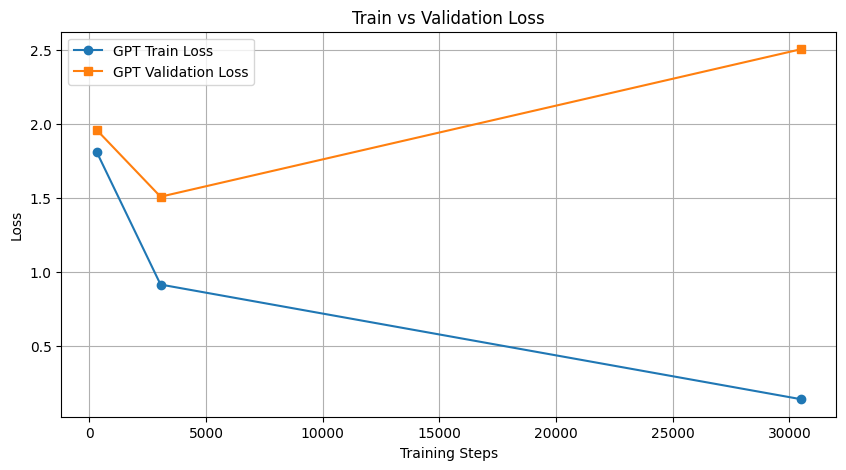

In [ ]:
import matplotlib.pyplot as plt

gpt_steps = [305, 3050, 30500]
gpt_train_losses = [1.8122, 0.9140, 0.1394]
gpt_val_losses = [1.9599, 1.5073, 2.5036]

plt.figure(figsize=(10, 5))
plt.plot(gpt_steps, gpt_train_losses, label='GPT Train Loss', marker='o')
plt.plot(gpt_steps, gpt_val_losses, label='GPT Validation Loss', marker='s')
plt.title('Train vs Validation Loss')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

**Task 1: Part B**

In [ ]:
# PyTorch LSTM Baseline
import torch.nn as nn
import pickle

# Load dataset
data_dir = 'data/shakespeare_char'
train_data = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
val_data = np.memmap(os.path.join(data_dir, 'val.bin'), dtype=np.uint16, mode='r')

with open(os.path.join(data_dir, 'meta.pkl'), 'rb') as f:
    meta = pickle.load(f)
stoi = meta['stoi']
itos = meta['itos']
vocab_size = meta['vocab_size']
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Define LSTM
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size=64, hidden_size=256, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        embed = self.embedding(x)
        out, hidden = self.lstm(embed, hidden)
        logits = self.fc(out)
        return logits, hidden

# Batch loader
def get_batch(split):
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    return x.to(device), y.to(device)

# Initialize model
lstm_model = CharLSTM(vocab_size).to(device)
optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Training loop
LSTM_steps = [305, 3050, 30500]
train_losses, val_losses = [], []

print("Training LSTM:")
for step in range(1, 30501):
    lstm_model.train()
    X, Y = get_batch('train')

    logits, _ = lstm_model(X)
    loss = criterion(logits.view(-1, vocab_size), Y.view(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step in LSTM_steps:
        lstm_model.eval()
        with torch.no_grad():
            X_val, Y_val = get_batch('val')
            val_logits, _ = lstm_model(X_val)
            val_loss = criterion(val_logits.view(-1, vocab_size), Y_val.view(-1))

        print(f"Step {step} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")
        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        # Save checkpoints
        torch.save(lstm_model.state_dict(), f"lstm_ckpt_step_{step}.pt")

Training LSTM:
Step 305 | Train Loss: 1.8237 | Val Loss: 1.9150
Step 3050 | Train Loss: 1.1538 | Val Loss: 1.5078
Step 30500 | Train Loss: 0.4412 | Val Loss: 3.2506


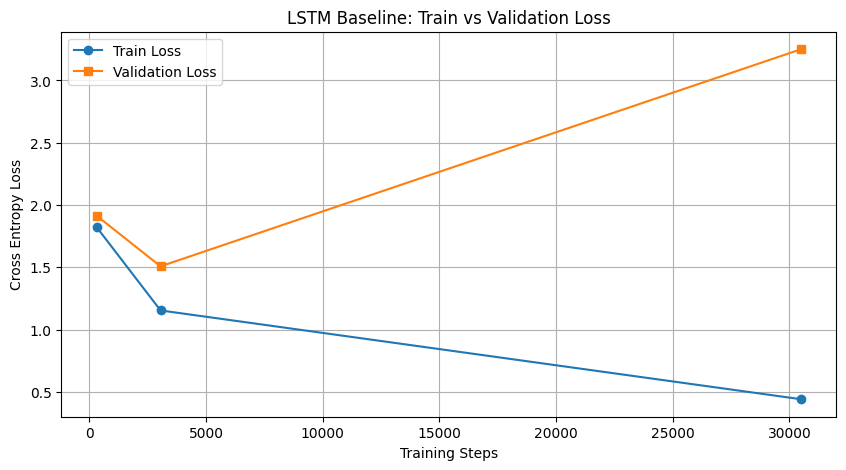

In [ ]:
# Plot
plt.figure(figsize=(10, 5))
plt.plot(LSTM_steps, train_losses, label='Train Loss', marker='o')
plt.plot(LSTM_steps, val_losses, label='Validation Loss', marker='s')
plt.title('LSTM Train vs Validation Loss')
plt.xlabel('Training Steps')
plt.ylabel('Cross Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# LSTM inference
import torch.nn.functional as F

def sample_lstm(model, start_text, num_chars=500, temperature=0.8, top_k=200):
    model.eval()
    chars = [stoi[c] for c in start_text]
    input_seq = torch.tensor(chars, dtype=torch.long).unsqueeze(0).to(device)
    hidden = None

    generated = start_text

    with torch.no_grad():
        for _ in range(num_chars):
            logits, hidden = model(input_seq, hidden)
            logits = logits[:, -1, :] / temperature

            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')

            probs = F.softmax(logits, dim=-1)
            next_char_idx = torch.multinomial(probs, num_samples=1).item()

            generated += itos[next_char_idx]
            input_seq = torch.tensor([[next_char_idx]], device=device)

    return generated

# Load checkpoints and generate samples
for step in LSTM_steps:
    print(f"\nLSTM step: {step}")
    lstm_model.load_state_dict(torch.load(f"lstm_ckpt_step_{step}.pt"))
    print(sample_lstm(lstm_model, "ROMEO: Juliet, I want ", num_chars=500))


LSTM step: 305
ROMEO: Juliet, I want lout?
Acfain they intertes woll ast high hath crage to
gefority his pillostime ank blood,
And that thince is my diving that with with hould the bid?

CINIIUS:
Mode,
At our dome Ethere the semarre harm hast berent beant of I purtle siced;
Why mid the diduson afversted can shade.

INGONES:
Sinlelve, thy son Monan
Of in is revertet in bictioun not and thee chard,
I his made then qearse, west, lives tour firters, it meing a marter tuming;
Shall
If he his not to bnoe to wenk mey.
Where be are meaty i

LSTM step: 3050
ROMEO: Juliet, I want in thee from
thee, in the wisand takes of meed wrong'd strick was that we
pressing to wail what they achieved thee to him.

PRINCE:
They have not done him condemness, and advanced
Every word and set him for blame and friends.

ESCALUS:
The curse where I did see his house, a little nor to
her his news was the lawful king; and to my brother side
Who I may put a thankings back him.
The most dread love thy heart I may be t

**Task 1: Part C**

* Performance comparison:

  * At the first checkpoint GPT and LSTM performance was similar. Train and val loss values were close. Both output responses that had correct structure with "SPEAKER: Lines...", but the sentences were gibberish and contained non-existent words.
  * At 50 epochs, the GPT model began to outperform LSTM: .91 training loss vs 1.2, with similar val loss. The model outputs do not make contextual sense or follow a logical conversation, but grammatical errors are far fewer. I believe the GPT output is slightly more coherent and logical.
  * After 500 epochs it was difficult for me to distinguish between the text outputs of the models. They are boths structurally sound and nearly grammatically correct, but the conversations taking place do not make sense. At this point the validation losses have spiked while training losses have continued to decrease, indicating overfitting.

* Significant differences:
  * I didn't detect any significant differences in outputs, but it seems that GPT has a better grasp of the conversational context. GPT's final output seems to represent a conversation about men's desire, while the LSTM final output seems more like a collection of individual unrelated statements.
  * This is likely due to the internal hidden state architecture of the LSTM, where over time the state forgets previous tokens and only remembers more recent context. GPT uses an attention mechanism, which helps the model to understand all past tokens and relate them to the next output.

###**Task 2**

* Problem: Predict future weather conditions using

* Dataset: https://www.kaggle.com/datasets/alistairking/weather-long-term-time-series-forecasting

* Why sequence models are needed:

  This data violates the assumption that data is i.i.d. since there is heavy dependence/correlation between data points. The temperature at one point is dependant on the previous data point, these are not independant. We need to use a model which accounts for this, RNNs process data sequentially, allowing them to identify patterns and relate each new data point to the previous ones.

**Task 2: Parts 1 & 2**

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "cleaned_weather.csv"
# Load dataset
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "alistairking/weather-long-term-time-series-forecasting",
  file_path,
)

print("First 5 records:", df.head())
print(df.shape)

/tmp/ipykernel_469/4283370284.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'weather-long-term-time-series-forecasting' dataset.
First 5 records:                   date        p     T    Tpot  Tdew    rh  VPmax  VPact  \
0  2020-01-01 00:10:00  1008.89  0.71  273.18 -1.33  86.1   6.43   5.54   
1  2020-01-01 00:20:00  1008.76  0.75  273.22 -1.44  85.2   6.45   5.49   
2  2020-01-01 00:30:00  1008.66  0.73  273.21 -1.48  85.1   6.44   5.48   
3  2020-01-01 00:40:00  1008.64  0.37  272.86 -1.64  86.3   6.27   5.41   
4  2020-01-01 00:50:00  1008.61  0.33  272.82 -1.50  87.4   6.26   5.47   

   VPdef    sh  ...      rho    wv  max. wv     wd  rain  raining  SWDR  PAR  \
0   0.89  3.42  ...  1280.62  1.02     1.60  224.3   0.0      0.0   0.0  0.0   
1   0.95  3.39  ...  1280.33  0.43     0.84  206.8   0.0      0.0   0.0  0.0   
2   0.96  3.39  ...  1280.29  0.61     1.48  197.1   0.0      0.0   0.0  0.0   
3   0.86  3.35  ...  1281.97  1.11     1.48  206.4   0.0      0.0   0.0  0.0   
4   0.79  3.38  ...  1282.08  0.49  

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

# Preprocess dataset
data = df['T'].values.reshape(-1, 1) # Target variable is temperature
# Normalize
scaler = MinMaxScaler(feature_range=(-1, 1))
data_normalized = scaler.fit_transform(data)

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length])
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

seq_length = 24 # Look back 24 hours
X, y = create_sequences(data_normalized, seq_length)

# Train, test, val split
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)

In [ ]:
# Model Implementations
import torch.nn as nn

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        rnn_out, hn = self.rnn(x)
        # Use final time step as output
        out = self.fc(rnn_out[:, -1, :])
        return out

class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        rnn_out, (hn, cn) = self.lstm(x)
        # Use final time step as output
        out = self.fc(rnn_out[:, -1, :])
        return out

class GRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(GRU, self).__init__()
        self.hidden_size = hidden_size
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        rnn_out, hn = self.gru(x)
        # Use final time step as output
        out = self.fc(rnn_out[:, -1, :])
        return out

My RNN is implemented using PyTorch's nn.RNN. My model has one hidden layer with 64 nodes. I use the tanh activation at each time step and a linear activation (fully connected layer) for the output. Tanh prevents hiddent states from growing too large and the output handles the regression task of predicting the temperature value.

I will use mean squared error to measure the performance of my model. This will help reduce large errors since it penalizes them more.

In [ ]:
# Training
def train_and_evaluate(model, model_name, epochs=50):
    criterion = nn.MSELoss() # Metric: mean squared error
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()

        # Validation
        model.eval()
        epoch_val_loss = 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                epoch_val_loss += loss.item()

        train_losses.append(epoch_train_loss / len(train_loader))
        val_losses.append(epoch_val_loss / len(val_loader))

    # Final test set evaluation
    model.eval()
    with torch.no_grad():
        test_predictions = model(X_test)
        test_loss = criterion(test_predictions, y_test).item()

    print(f"{model_name} - Test MSE: {test_loss:.4f}")
    return train_losses, val_losses

Training models...
RNN - Test MSE: 0.0001
LSTM - Test MSE: 0.0000
GRU - Test MSE: 0.0001


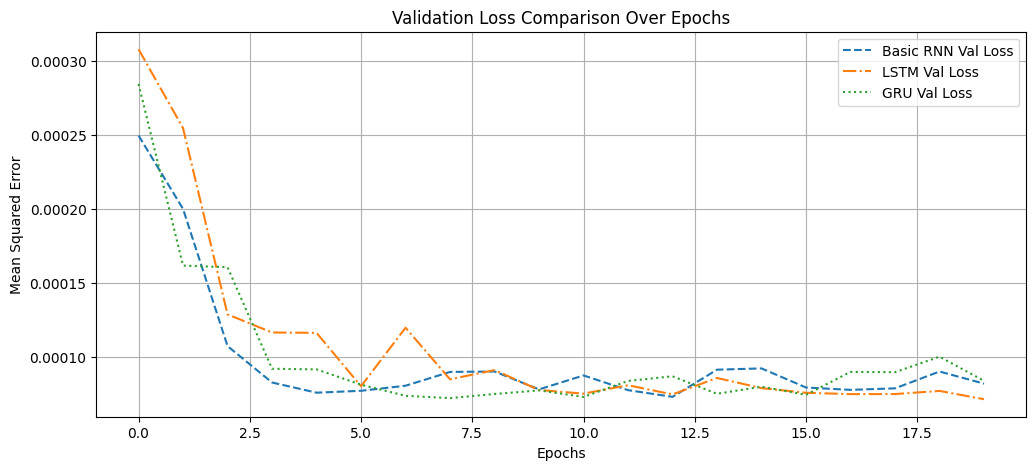

In [ ]:
# Print results
print("Training models...")

# Define hyperparameters
input_size = 1
hidden_size = 64
output_size = 1

# Define models
rnn = RNN(input_size, hidden_size, output_size)
lstm = LSTM(input_size, hidden_size, output_size)
gru = GRU(input_size, hidden_size, output_size)

# Train
rnn_train, rnn_val = train_and_evaluate(rnn, 'RNN', epochs=20)
lstm_train, lstm_val = train_and_evaluate(lstm, 'LSTM', epochs=20)
gru_train, gru_val = train_and_evaluate(gru, 'GRU', epochs=20)

# Plot results
plt.figure(figsize=(12, 5))
plt.plot(rnn_val, label='Basic RNN Val Loss', linestyle='--')
plt.plot(lstm_val, label='LSTM Val Loss', linestyle='-.')
plt.plot(gru_val, label='GRU Val Loss', linestyle=':')
plt.title('Validation Loss Comparison Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

I don't notice many "major" differences, as all models converge around 5 epochs. The LSTM started with the highest loss, and its loss function oscillated more during the first 7.5 epochs, with loss spiking and then coming back down. The RNN and GRU are similar, with the RNN generally performing better in the first 5 epochs and last 2.5 epochs.

The LSTM ultimately acheives the lowest loss, which is likely due to its more complex internal cell state which allow it to learn deeper relationships. The RNN and GRU use more simplier approaches, which allow them to learn a similar level of complexity from this dataset.

**Task 2: Part 3**

Yes, we could alter our approach to the problem to use a feed-forward network to solve this. This would require converting our time-series data points to form one vector per designated time period. This would treat each time period as a single data point which could be used by the feed-forward network.

This is a worse approach for this problem, as it makes it more difficult for the model to learn seasonal (long-term) patterns, and it would require the model to relearn different patterns based on each feature in the input, where features will be redundant and share characteristics that could otherwise be learned once.

###**Task 3**

**Task 3: Part 1**

In [ ]:
# BERT Embeddings
import torch
from transformers import BertTokenizer, BertModel

# Load embeddings
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
model.eval()

def get_bert_embedding(word):
    inputs = tokenizer(word, return_tensors='pt')
    with torch.no_grad():
        outputs = model(**inputs)
    # Output is average of last hidden states
    return outputs.last_hidden_state.mean(dim=1).numpy()

def user_input():
    # Capture user inputs and embedds them
    word1 = input("Enter the first word: ")
    word2 = input("Enter the second word: ")

    emb1 = get_bert_embedding(word1)
    emb2 = get_bert_embedding(word2)

    print(f"\nEmbedding for '{word1}' shape: {emb1.shape}")
    print(f"Embedding for '{word2}' shape: {emb2.shape}")
    return word1, emb1, word2, emb2

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
w1, e1, w2, e2 = user_input()

Enter the first word: cat
Enter the second word: dog

Embedding for 'cat' shape: (1, 768)
Embedding for 'dog' shape: (1, 768)


I chose BERT embeddings over the others due to it having contextual embeddings and personal interest in the BERT model. BERT will generate a different embedding for the same word if the surrounding context is different. BERT automatically handles OOV, it breaks words down into known subparts, so any english language word will be in vocab.

**Task 3: Part 2**

Batch Similarity Results:
chair vs desk: 0.8511
cat vs dog: 0.9009
apple vs banana: 0.9216

PCA visualization:


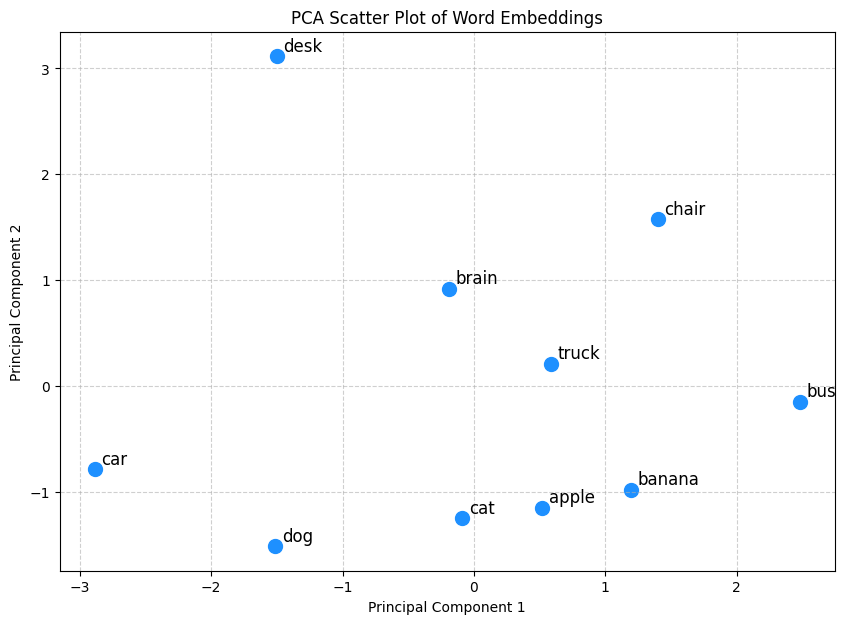

In [ ]:
# Cosine Similarity
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

def batch_similarity(word_pairs):
    # Calls cosine similarity for batches
    results = {}
    for w1, w2 in word_pairs:
        e1 = get_bert_embedding(w1)
        e2 = get_bert_embedding(w2)
        results[f"{w1} vs {w2}"] = cosine_similarity(e1, e2)[0][0]
    return results

# Batch Processing
test_pairs = [("chair", "desk"), ("cat", "dog"), ("apple", "banana")]
print("Batch Similarity Results:")
for pair, score in batch_similarity(test_pairs).items():
    print(f"{pair}: {score:.4f}")

# PCA Visualization
words_to_plot = ["cat", "dog", "desk", "chair", "car", "truck", "bus", "apple", "banana", "brain"]
print(f"\nPCA visualization:")
embeddings = np.vstack([get_bert_embedding(w) for w in words_to_plot])

# Reduce dimensionality for PCA
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# Plot
plt.figure(figsize=(10, 7))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], color='dodgerblue', s=100)

for i, word in enumerate(words_to_plot):
    plt.annotate(word, (reduced_embeddings[i, 0] + 0.05, reduced_embeddings[i, 1] + 0.05), fontsize=12)

plt.title("PCA Scatter Plot of Word Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Cosine similarity is useful because it helps understand the difference or similarity in meaning of embeddings. In the vector space, the direction of the vector represents meaning, and cosine similarity measures the similarity of direction, helping us quantify similarity and difference in meaning.

**Task 3: Part 3**

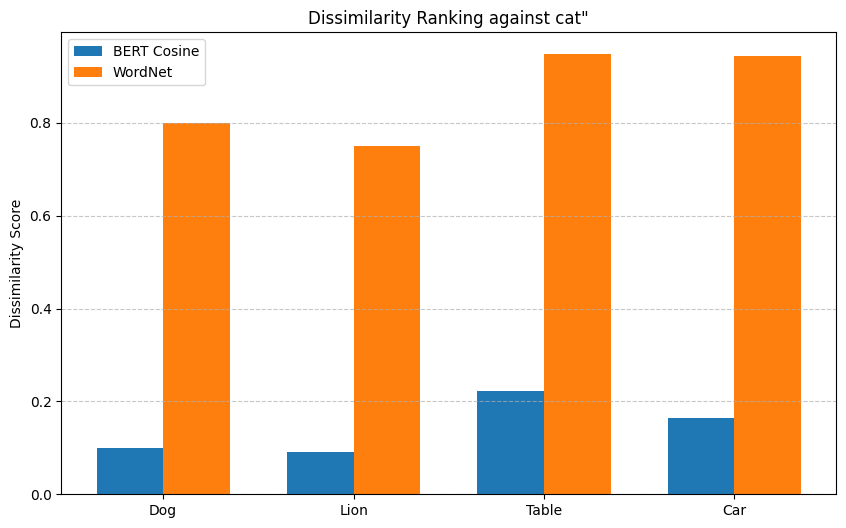

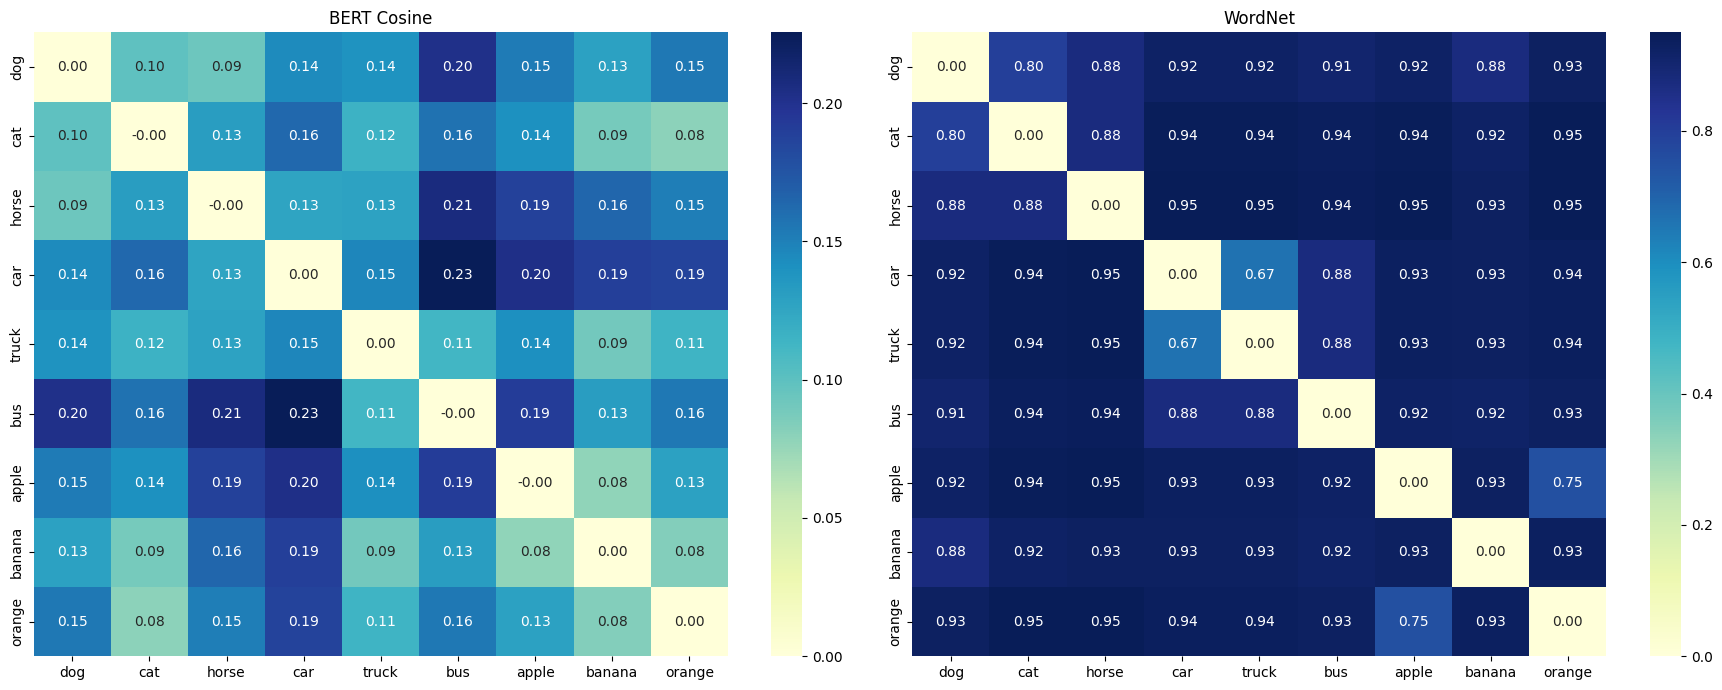

In [ ]:
# Dissimilarity Metric
import nltk
import seaborn as sns
from nltk.corpus import wordnet as wn

# Download wordnet
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

def calculate_dissimilarity(word1, word2, metric='cosine'):
    # Calculates dissimilarity
    if metric == 'cosine':
        emb1 = get_bert_embedding(word1)
        emb2 = get_bert_embedding(word2)
        return 1.0 - cosine_similarity(emb1, emb2)[0][0]

    elif metric == 'wordnet':
        # Use WordNet dissimilarity
        synsets1 = wn.synsets(word1)
        synsets2 = wn.synsets(word2)

        if not synsets1 or not synsets2:
            return 1.0 # Max dissimilarity if OOV

        path_sim = synsets1[0].path_similarity(synsets2[0])
        if path_sim is None:
            return 1.0
        return 1.0 - path_sim

# Compare cat dissimilarity to other words
target_word = "cat"
comparison_words = ["dog", "lion", "table", "car"]

cosine_scores = [calculate_dissimilarity(target_word, w, metric='cosine') for w in comparison_words]
wordnet_scores = [calculate_dissimilarity(target_word, w, metric='wordnet') for w in comparison_words]

x = np.arange(len(comparison_words))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, cosine_scores, width, label='BERT Cosine')
ax.bar(x + width/2, wordnet_scores, width, label='WordNet')

ax.set_ylabel('Dissimilarity Score')
ax.set_title(f'Dissimilarity Ranking against cat"')
ax.set_xticks(x)
ax.set_xticklabels([w.capitalize() for w in comparison_words])
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Similarity heatmap
category_words = ["dog", "cat", "horse", "car", "truck", "bus", "apple", "banana", "orange"]
n = len(category_words)

matrix_cosine = np.zeros((n, n))
matrix_wordnet = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        matrix_cosine[i, j] = calculate_dissimilarity(category_words[i], category_words[j], metric='cosine')
        matrix_wordnet[i, j] = calculate_dissimilarity(category_words[i], category_words[j], metric='wordnet')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(matrix_cosine, xticklabels=category_words, yticklabels=category_words,
            ax=axes[0], cmap="YlGnBu", annot=True, fmt=".2f")
axes[0].set_title("BERT Cosine")

sns.heatmap(matrix_wordnet, xticklabels=category_words, yticklabels=category_words,
            ax=axes[1], cmap="YlGnBu", annot=True, fmt=".2f")
axes[1].set_title("WordNet")

plt.tight_layout()
plt.show()

Custom dissimilarity score: Semantic contrast measure using WordNet

Citation: WordNet paper. https://dl.acm.org/doi/pdf/10.1145/219717.219748

This captures disimilarity better than cosine similarity alone because it helps to prevent context from interferring with our similarity. This method prevents words that appear in similar contexts from being grouped together, since WordNet attempts to measure the difference in what the words actually mean, instead of measuring the difference in how often they share surrounding words in a sentence.